### **1. Introduction**

This notebook is to provide explainability for the soil zones generated using K-Means clustering. 
Since the model is unsupervised, explainability is achieved through post-hoc analysis of cluster centroids and feature deviations rather than prediction-based methods.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

### **2. Load Clustered Dataset**

In [7]:
df = pd.read_csv("../outputs/soil_clusters.csv")

features = [
    "taw",
    "organic_carbon",
    "cec",
    "ph",
    "sand_pct"
]

X = df[features]
y = df["cluster"]

### **3. Scale Features for Interpretability**

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

### **4. Compute Cluster Means Vs Global Mean**

In [9]:
global_mean = X_scaled_df.mean()

cluster_means = (
    X_scaled_df
    .groupby(df["cluster"])
    .mean()
)

deviation = cluster_means - global_mean
deviation

,taw,organic_carbon,cec,ph,sand_pct
cluster,,,,,
0,1.795962,-1.101721,0.428829,0.967773,0.422534
1,-0.599355,-0.600889,-1.201932,-0.355352,-0.122376
2,-0.932307,-0.360482,0.560653,1.589571,1.560045
3,0.513478,1.098355,0.905937,-0.573246,-0.650740


### **5. Visualize Deviations**

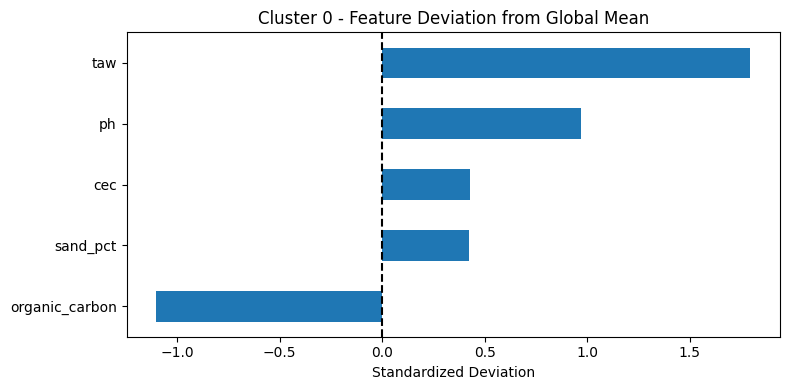

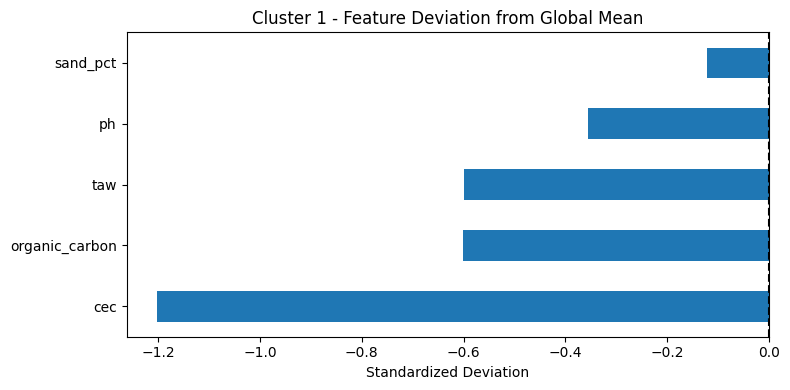

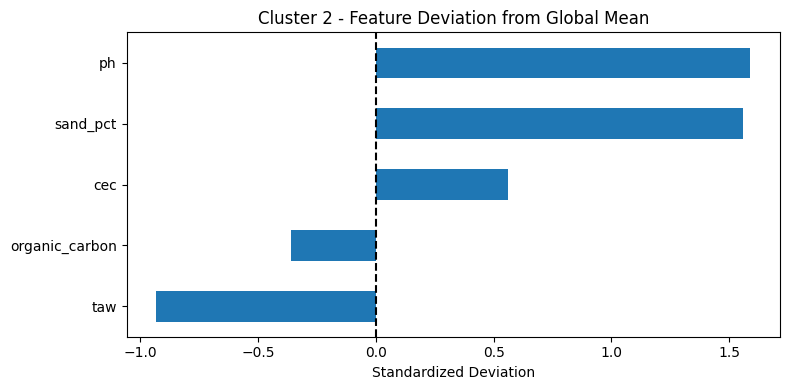

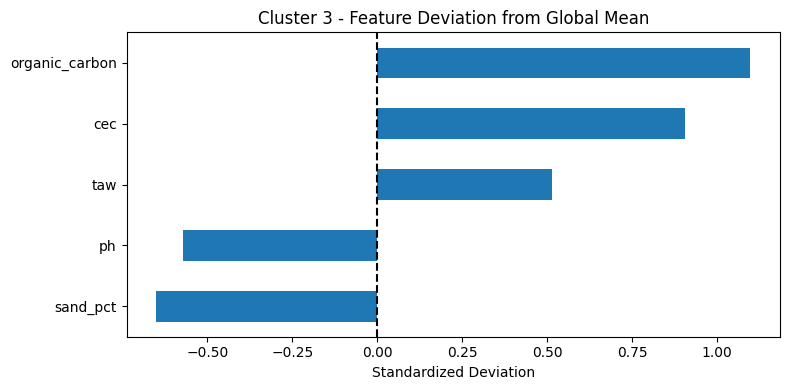

In [10]:
for c in deviation.index:
    plt.figure(figsize=(8, 4))
    deviation.loc[c].sort_values().plot(kind="barh")
    plt.axvline(0, color="black", linestyle="--")
    plt.title(f"Cluster {c} - Feature Deviation from Global Mean")
    plt.xlabel("Standardized Deviation")
    plt.tight_layout()
    plt.show()


### **6. XAI-Aligned Cluster-by-Cluster Interpretation**

The above values represent standardized deviations from the global average soil condition. The magnitude of the absolute value reflects how strongly a given feature characterizes the cluster, with larger absolute values representing more defining soil properties.
$$
\begin{array}{c l}
0 & \text{=  Global average soil} \\
+ & \text{=  Higher than average} \\
- & \text{=  Lower than average}
\end{array}
$$

#### **Cluster 0**
$$
\begin{array}{l c l}
\textbf{Feature} & \textbf{Deviation} & \textbf{Meaning} \\
\hline
\text{TAW} & +1.80 & \text{Extremely high water holding} \\
\text{Organic Carbon} & -1.10 & \text{Very low organic matter} \\
\text{CEC} & +0.43 & \text{Moderate nutrient holding} \\
\text{pH} & +0.97 & \text{Moderately less acidic} \\
\text{Sand \%} & +0.42 & \text{Moderately sandy}
\end{array}
$$

#### **Cluster 1**
$$
\begin{array}{l c l}
\textbf{Feature} & \textbf{Deviation} & \textbf{Meaning} \\
\hline
\text{TAW} & -0.60 & \text{Low water holding} \\
\text{Organic Carbon} & -0.60 & \text{Low organic matter} \\
\text{CEC} & -1.20 & \text{Very poor nutrient holding} \\
\text{pH} & -0.36 & \text{Acidic} \\
\text{Sand \%} & -0.12 & \text{Near average texture}
\end{array}
$$

#### **Cluster 2**
$$
\begin{array}{l c l}
\textbf{Feature} & \textbf{Deviation} & \textbf{Meaning} \\
\hline
\text{TAW} & -0.93 & \text{Very low water holding} \\
\text{Organic Carbon} & -0.36 & \text{Slightly low OC} \\
\text{CEC} & +0.56 & \text{Moderate nutrient holding} \\
\text{pH} & +1.59 & \text{Highest pH} \\
\text{Sand \%} & +1.56 & \text{Extremely sandy}
\end{array}
$$

#### **Cluster 3**
$$
\begin{array}{l c l}
\textbf{Feature} & \textbf{Deviation} & \textbf{Meaning} \\
\hline
\text{TAW} & +0.51 & \text{Good water holding} \\
\text{Organic Carbon} & +1.10 & \text{Very high OC} \\
\text{CEC} & +0.91 & \text{High nutrient holding} \\
\text{pH} & -0.57 & \text{Acidic} \\
\text{Sand \%} & -0.65 & \text{Fine textured}
\end{array}
$$

<br><br>The centroid deviation analysis reveals that each soil cluster is characterized by distinct physical and chemical drivers. Cluster 0 is primarily defined by exceptionally high TAW, while Cluster 1 is constrained by low CEC and acidity. Cluster 2 is dominated by extreme sand content and low water availability but maintains moderate chemical fertility. Cluster 3 exhibits the highest organic carbon and CEC, indicating strong nutrient retention capacity despite acidic conditions. These results quantitatively validate the agronomic interpretations assigned to each soil zone.



